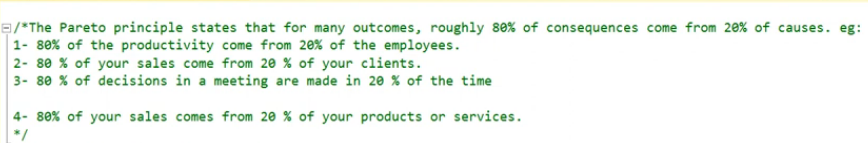

In [ ]:
with product_wise_sales as (
    select product_id,sum(sales) as product_sales from orders group by product_id
),calc_sales as (
select 
product_id,
product_sales,
sum(product_sales) over(order by product_sales desc rows BETWEEN unbounded preceding and 0 preceding) as running_sales, 
0.8*sum(product_sales) over() as total_sales from product_wise_sales)
select * from calc_sales where running_sales <=total_sales